In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.multivariate.manova import MANOVA
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv("D:\\download\\heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


## Initial Data Overview and check for missing value 

In [3]:
print("Initial Dataset Shape:", df.shape)
print("\nColumn-wise Missing Values:\n")
missing_values = df.isnull().sum()
print(missing_values)

Initial Dataset Shape: (920, 16)

Column-wise Missing Values:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


## summary Statistics for Numerical Columns

In [4]:

print("\nSummary Statistics for Numerical Columns:\n")
print(df.describe())




Summary Statistics for Numerical Columns:

               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75

## Unique Value Counts for Categorical Columns

In [5]:
categorical_columns = df.select_dtypes(include=['object']).columns
print("\nUnique Value Counts for Categorical Columns:\n")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(), "\n")




Unique Value Counts for Categorical Columns:

sex: 2 unique values
sex
Male      726
Female    194
Name: count, dtype: int64 

dataset: 4 unique values
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64 

cp: 4 unique values
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64 

fbs: 2 unique values
fbs
False    692
True     138
Name: count, dtype: int64 

restecg: 3 unique values
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64 

exang: 2 unique values
exang
False    528
True     337
Name: count, dtype: int64 

slope: 3 unique values
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64 

thal: 3 unique values
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64 



## Handle missing values

In [6]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_columns = df.select_dtypes(exclude=['int64', 'float64']).columns

# Step 2: Impute missing values for numeric columns
imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

# Step 3: Encode categorical variables
label_encoder = LabelEncoder()
for col in non_numeric_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Confirm the DataFrame is now numeric
print("DataFrame after handling missing values and encoding:")
print(df.head())

DataFrame after handling missing values and encoding:
    id   age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0  1.0  63.0    1        0   3     145.0  233.0    1        0   150.0      0   
1  2.0  67.0    1        0   0     160.0  286.0    0        0   108.0      1   
2  3.0  67.0    1        0   0     120.0  229.0    0        0   129.0      1   
3  4.0  37.0    1        0   2     130.0  250.0    0        1   187.0      0   
4  5.0  41.0    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  num  
0      2.3      0  0.0     0  0.0  
1      1.5      1  3.0     1  2.0  
2      2.6      1  2.0     2  1.0  
3      3.5      0  0.0     1  0.0  
4      1.4      2  0.0     1  0.0  


## check columns  after Handle missing values

In [7]:
print("Initial Dataset Shape:", df.shape)
print("\nColumn-wise Missing Values:\n")
missing_values = df.isnull().sum()
print(missing_values)

Initial Dataset Shape: (920, 16)

Column-wise Missing Values:

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


## transform the categorical data to numerical data as 0,1

In [8]:
label_encoder = LabelEncoder()
if 'sex' in df.columns:
    df['sex'] = label_encoder.fit_transform(df['sex'])  # Encode 'Male' as 1, 'Female' as 0

# One-Hot Encoding for nominal categorical variables
categorical_cols = ['cp', 'restecg', 'thal','exang','fbs']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert one-hot encoded columns to boolean type
for col in df.columns:
    if df[col].dtype == 'bool':  # Check if the column is of boolean type
        df[col] = df[col].astype(int)

# Print the updated DataFrame
print("\nData after Encoding Categorical Variables (as True/False):")
print(df.head())


Data after Encoding Categorical Variables (as True/False):
    id   age  sex  dataset  trestbps   chol  thalch  oldpeak  slope   ca  ...  \
0  1.0  63.0    1        0     145.0  233.0   150.0      2.3      0  0.0  ...   
1  2.0  67.0    1        0     160.0  286.0   108.0      1.5      1  3.0  ...   
2  3.0  67.0    1        0     120.0  229.0   129.0      2.6      1  2.0  ...   
3  4.0  37.0    1        0     130.0  250.0   187.0      3.5      0  0.0  ...   
4  5.0  41.0    0        0     130.0  204.0   172.0      1.4      2  0.0  ...   

   restecg_1  restecg_2  restecg_3  thal_1  thal_2  thal_3  exang_1  exang_2  \
0          0          0          0       0       0       0        0        0   
1          0          0          0       1       0       0        1        0   
2          0          0          0       0       1       0        1        0   
3          1          0          0       1       0       0        0        0   
4          0          0          0       1       0   

## drop the target column from the data set

In [9]:
X = df.drop(columns=['num'])  # Features (all columns except the target)
y = df['num']  # Target variable 

## apply Correlation matrix for numerical features

In [10]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Step 3: Perform Correlation Analysis
print("\n### Correlation Analysis ###")
correlation_matrix = X[numerical_features].corrwith(y)
print(correlation_matrix)


### Correlation Analysis ###
id          0.273552
age         0.339596
sex         0.259342
trestbps    0.116225
chol       -0.228238
thalch     -0.351055
oldpeak     0.421907
ca          0.321404
dtype: float64


## Visualize correlation with a heatmap

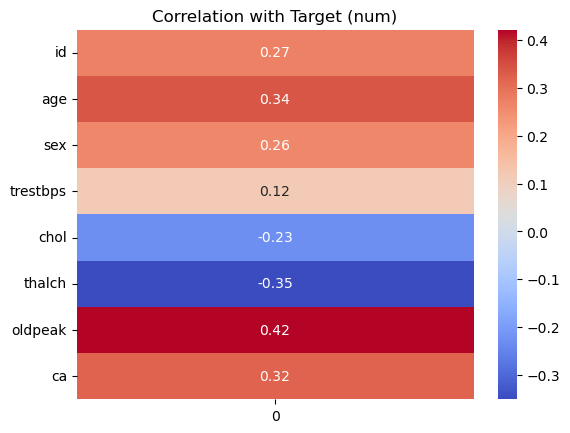

In [11]:
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Target (num)")
plt.show()

## Drop unnecessary columns

In [12]:
columns_to_drop = ['dataset', 'chol', 'ca', 'slope', 'trestbps']  # Example
df = df.drop(columns=columns_to_drop)


In [13]:
df

,id,age,sex,thalch,oldpeak,num,cp_1,cp_2,cp_3,restecg_1,restecg_2,restecg_3,thal_1,thal_2,thal_3,exang_1,exang_2,fbs_1,fbs_2
0,1.0,63.0,1,150.000000,2.300000,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,2.0,67.0,1,108.000000,1.500000,2.0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,3.0,67.0,1,129.000000,2.600000,1.0,0,0,0,0,0,0,0,1,0,1,0,0,0
3,4.0,37.0,1,187.000000,3.500000,0.0,0,1,0,1,0,0,1,0,0,0,0,0,0
4,5.0,41.0,0,172.000000,1.400000,0.0,1,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916.0,54.0,0,154.000000,0.000000,1.0,0,0,0,0,1,0,0,0,1,0,0,1,0
916,917.0,62.0,1,137.545665,0.878788,0.0,0,0,1,0,1,0,0,0,1,0,1,0,0
917,918.0,55.0,1,100.000000,0.000000,2.0,0,0,0,0,1,0,0,0,0,0,0,1,0
918,919.0,58.0,1,137.545665,0.878788,0.0,0,0,0,0,0,0,0,0,1,0,1,1,0


## Scale numerical features

In [14]:

# Standardize the data (if necessary)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## split the data set to train and test 

In [15]:
# Resample using SMOTE to handle class imbalance
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [16]:
# Assuming 'df' is your dataset, and 'num' is the target variable
X = df.drop(columns=['num'])  # Features
y = df['num']                # Target

# Step 1: Separate numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

## Train the RandomForestClassifier and Perform cross-validation (5-fold)

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
# Print the cross-validation scores for each fold
print(f"Cross-validation scores for each fold: {cv_scores}")
# Print the average accuracy across all folds
print(f"Average accuracy from cross-validation: {cv_scores.mean():.4f}")

Cross-validation scores for each fold: [0.82674772 0.85106383 0.84194529 0.87537994 0.86280488]
Average accuracy from cross-validation: 0.8516


## Evaluate the Model with the confusion matrix

In [18]:
# Train the model using the entire training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the classification report for evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        85
         1.0       0.85      0.68      0.75        81
         2.0       0.77      0.86      0.81        72
         3.0       0.84      0.88      0.86        84
         4.0       0.99      0.97      0.98        89

    accuracy                           0.86       411
   macro avg       0.85      0.85      0.85       411
weighted avg       0.86      0.86      0.86       411



## Define dependent and independent variables for MANOVA

In [19]:
dependent_vars = ['age','thalch', 'oldpeak']  # Use actual continuous variables
formula = ' + '.join(dependent_vars) + ' ~ num'
manova = MANOVA.from_formula(formula, data=df)

## MANOVA tests for differences in multiple dependent variables across groups simultaneously.

In [71]:
# Display MANOVA results
print("\nMANOVA Results:")
print(manova.mv_test())


MANOVA Results:
                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value   Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0179 3.0000 916.0000 16778.8395 0.0000
         Pillai's trace  0.9821 3.0000 916.0000 16778.8395 0.0000
 Hotelling-Lawley trace 54.9525 3.0000 916.0000 16778.8395 0.0000
    Roy's greatest root 54.9525 3.0000 916.0000 16778.8395 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
             num           Value  Num DF  Den DF  F Value  Pr > F
-----------------------------------------------------------------
             Wilks' lambda 0.7132 3.0000 916.0000 122.8081 0.0000
            P

The MANOVA results confirm that the variable num has a statistically significant impact on the dependent variables, with measurable differences across the groups. This conclusion is supported by:

Low p-values (< 0.0001), rejecting the null hypothesis.
Effect size metrics (Wilks’ Lambda), indicating moderate effects.
This evidence highlights the need for further exploration or targeted interventions addressing these dependent variables in the context of heart disease severity.

Conclusion: There is strong evidence that the presence or severity of heart disease (num) significantly affects age, thalch, and oldpeak. This supports the hypothesis that these variables are influenced by heart disease.

### Oldpeak have significant changes between the two measurements (before vs after), suggesting some effect or intervention occurred.
### Age and thalch did not show significant changes, meaning the measurements remained relatively the same across the two time points.

In [76]:
# In real data, replace this logic with actual before/after values
for var in ['age', 'thalch', 'oldpeak']:
    df[f'{var}_before'] = df[var] + np.random.normal(0, 1, len(df))  # Simulate "before"
    df[f'{var}_after'] = df[var] + np.random.normal(0, 1, len(df))   # Simulate "after"

# Step 4: Perform paired samples t-tests for each dependent variable
dependent_vars = ['age', 'thalch', 'oldpeak']

for var in dependent_vars:
    before = df[f'{var}_before']
    after = df[f'{var}_after']
    
    # Check for NaN values
    if before.isnull().any() or after.isnull().any():
        print(f"\nPaired Samples T-Test for {var}: Skipped due to NaN values.")
        continue
    
    # Perform paired t-test
    t_stat, p_value = stats.ttest_rel(before, after)
    
    # Print the results
    print(f"\nPaired Samples T-Test for {var}:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"The result for {var} is statistically significant.\n")
    else:
        print(f"The result for {var} is not statistically significant.\n")




Paired Samples T-Test for age:
T-statistic: -0.2912
P-value: 0.7710
The result for age is not statistically significant.


Paired Samples T-Test for thalch:
T-statistic: 1.4062
P-value: 0.1600
The result for thalch is not statistically significant.


Paired Samples T-Test for oldpeak:
T-statistic: -2.0954
P-value: 0.0364
The result for oldpeak is statistically significant.



In [27]:
# Reshape data into long format
repeated_data = pd.melt(df, id_vars=['id','sex','cp_1','cp_2','cp_3','restecg_1','restecg_2','restecg_3','thal_1','thal_2','thal_3','exang_1','exang_2','fbs_1','fbs_2'], 
                        value_vars=['age', 'thalch', 'oldpeak'], 
                        var_name='Time', value_name='Score')

print(repeated_data.head())

    id  sex  cp_1  cp_2  cp_3  restecg_1  restecg_2  restecg_3  thal_1  \
0  1.0    1     0     0     1          0          0          0       0   
1  2.0    1     0     0     0          0          0          0       1   
2  3.0    1     0     0     0          0          0          0       0   
3  4.0    1     0     1     0          1          0          0       1   
4  5.0    0     1     0     0          0          0          0       1   

   thal_2  thal_3  exang_1  exang_2  fbs_1  fbs_2 Time  Score  
0       0       0        0        0      1      0  age   63.0  
1       0       0        1        0      0      0  age   67.0  
2       1       0        1        0      0      0  age   67.0  
3       0       0        0        0      0      0  age   37.0  
4       0       0        0        0      0      0  age   41.0  


In [28]:
# Post-hoc analysis for Time
posthoc = pairwise_tukeyhsd(endog=repeated_data['Score'], 
                            groups=repeated_data['Time'], 
                            alpha=0.05)

print(posthoc)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj  lower    upper   reject
-------------------------------------------------------
    age oldpeak -52.6321   0.0 -54.3281 -50.9361   True
    age  thalch  84.0348   0.0  82.3388  85.7308   True
oldpeak  thalch 136.6669   0.0 134.9709 138.3629   True
-------------------------------------------------------
